In [1]:
%load_ext cudf.pandas
%load_ext cuml.accel

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
!pip install nltk

In [4]:
import nltk
nltk.download("stopwords")
nltk.download("punkt")
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
from nltk.tokenize import word_tokenize, TweetTokenizer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Data Loading

dataset source: https://www.kaggle.com/datasets/thoughtvector/customer-support-on-twitter?resource=download

In [ ]:
data = pd.read_csv("dataset\Twcs.csv")
data.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,None,1
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6


In [7]:
data.info()

<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 2812111 entries, 0 to 2812110
Data columns (total 7 columns):
 #   Column                   Dtype
---  ------                   -----
 0   tweet_id                 object
 1   author_id                object
 2   inbound                  object
 3   created_at               object
 4   text                     object
 5   response_tweet_id        object
 6   in_response_to_tweet_id  object
dtypes: object(7)
memory usage: 545.7+ MB


In [8]:
data = data[data['inbound']=="True"]
data.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,None,1
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6
6,8,115712,True,Tue Oct 31 21:45:10 +0000 2017,@sprintcare is the worst customer service,"9,6,10",None
8,12,115713,True,Tue Oct 31 22:04:47 +0000 2017,@sprintcare You gonna magically change your co...,"11,13,14",15


In [9]:
data = data.sample(n=10000, random_state=42)

In [10]:
data = data['text']
data.head()

,text
1637757,@AppleSupport How can I associate two apple ac...
2231184,@689427 @sainsburys @556129 No stunning and no...
97910,"@sizehelpteam hey i want to cancel my order , ..."
2427896,@Uber_Support I guess I just forgot how doo do...
1106017,@AppleSupport Y is the feature not like iOS 10...


In [11]:
data.info()

<class 'pandas.core.series.Series'>
Index: 10000 entries, 1637757 to 2622570
Series name: text
Non-Null Count  Dtype 
--------------  ----- 
10000 non-null  object
dtypes: object(1)
memory usage: 156.2+ KB


In [12]:
empty_strings = ((data == "") | (data == " ") | (data == "NA") | (data == "na") | (data == "None")).sum()
print(f"Empty strings: {empty_strings}")

Empty strings: 0


In [13]:
data = data.reset_index(drop=True)

In [14]:
data.info()

<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: text
Non-Null Count  Dtype 
--------------  ----- 
10000 non-null  object
dtypes: object(1)
memory usage: 78.3+ KB


# Text Pre Processing

## Regex to clean the data

In [15]:
import re
import string

In [16]:
data[500]

'@444765 @Safaricom_Care The response! 333 is PR no.\nBeen reminded by Safaricom, as if I needed it, that I "ignore" the scammer\'s number. Must be a robot.'

In [17]:
def clean(tweet):
    tweet1 = re.sub(r"^@\w+",'',tweet)
    tweet1 = re.sub(r'[#?.,]', '', tweet1)
    tweet1 = re.sub(r'\d+', '', tweet1)
    tweet1 = re.sub(r'\s+', ' ', tweet1).strip()
    tweet1 = re.sub(r'https?://\S+', '', tweet1)

    return tweet1


In [18]:
text_list = data.tolist()
text_list[:5]

['@AppleSupport How can I associate two apple accounts on one device?',
 '@689427 @sainsburys @556129 No stunning and not many prayers being said just a cruel and barbaric way of killing these poor animals',
 '@sizehelpteam hey i want to cancel my order , this is the reference : 83971633',
 '@Uber_Support I guess I just forgot how doo doo brown your service was.',
 '@AppleSupport Y is the feature not like iOS 10 just turn off/on so simple.. why again turn on at 5 am???']

In [19]:
clean_tweet = [clean(tweet) for tweet in text_list]

In [20]:
clean_tweet[:5]

['How can I associate two apple accounts on one device',
 '@sainsburys @ No stunning and not many prayers being said just a cruel and barbaric way of killing these poor animals',
 'hey i want to cancel my order this is the reference :',
 'I guess I just forgot how doo doo brown your service was',
 'Y is the feature not like iOS just turn off/on so simple why again turn on at am']

In [21]:
stop_words = set(stopwords.words('english'))
neg_words = {'no', 'not', 'nor', 'neither', 'never', 'none'}
stop_words = stop_words - neg_words

In [22]:
Lemmetizer = WordNetLemmatizer()
Tweet_Tokenize = TweetTokenizer(preserve_case=False,reduce_len=True,strip_handles=True)

In [23]:
lemmetized_tweet = []

In [24]:
def preprocess(tweet):
    temp = []
    tokens = Tweet_Tokenize.tokenize(tweet)
    for word in tokens:
        if word not in stop_words and word not in string.punctuation:
            res = Lemmetizer.lemmatize(word)
            res = res.lower()
            temp.append(res)
    lemmetized_tweet.append(" ".join(temp))


In [25]:
for tweet in clean_tweet:
    preprocess(tweet)

In [26]:
lemmetized_tweet[1]

'no stunning not many prayer said cruel barbaric way killing poor animal'

## TF-IDF

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [28]:
vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=5000,
    min_df=5,
    max_df=0.7
)

In [29]:
X = vectorizer.fit_transform(lemmetized_tweet)

## Unsupervised part

In [30]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100, random_state=42)
reduced_X = svd.fit_transform(X)


## Kmeans

In [31]:
from sklearn.cluster import KMeans,kmeans_plusplus
from sklearn.metrics import silhouette_score

In [32]:
X[:5].toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [33]:
inertia = []
sil_scores = []
k_range = range(2,50)

for k in k_range:
    km = KMeans(n_clusters=k,init='k-means++',random_state=42)
    km.fit(reduced_X)

    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(reduced_X,km.labels_))

Text(0, 0.5, 'Inertia')

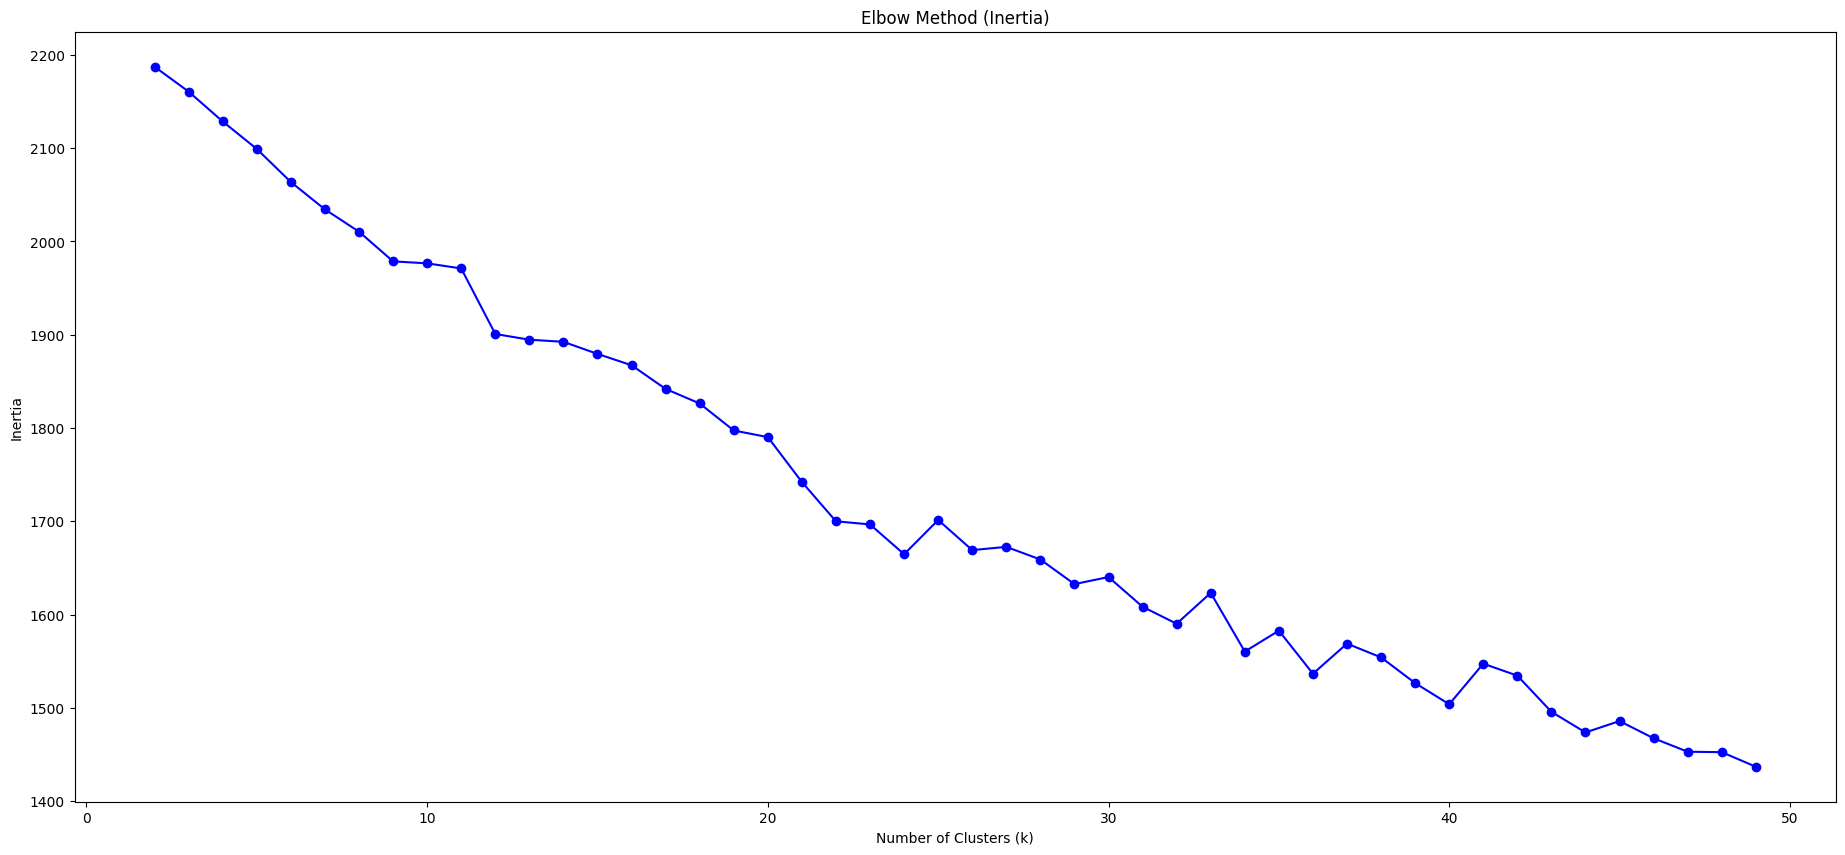

In [34]:
plt.figure(figsize=(50, 10))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o', color='b')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

In [35]:
cluster = 2
for score in sil_scores:
    print(cluster,score)
    cluster+=1

2 0.07153381392592591
3 0.07573875087159097
4 0.11453863233336961
5 0.07403129995972259
6 0.047792227665694006
7 0.05176079455960483
8 0.03412135211945298
9 0.07816477135696501
10 0.05691919178050416
11 0.05869945531104602
12 0.060074315564982564
13 0.0667438585317736
14 0.05622247703417837
15 0.06911510638442797
16 0.06008266507294919
17 0.07208385746735421
18 0.06543682770938716
19 0.07021677490730137
20 0.07962667125134273
21 0.0787700766761832
22 0.08462977782801849
23 0.08211196538337828
24 0.08542207849374385
25 0.07507883701330861
26 0.08312678995217962
27 0.08303450080612093
28 0.08117927742186794
29 0.08770086274994135
30 0.08768496830246793
31 0.09023158875275837
32 0.09967770873765433
33 0.09298081730529915
34 0.09528729215427675
35 0.09119376278031034
36 0.09757950285274737
37 0.09521580089417438
38 0.09159230227395096
39 0.10528115629317121
40 0.10022469252120997
41 0.08320515044080394
42 0.10370877570370114
43 0.10124587137021748
44 0.10598925911498268
45 0.09683439191759

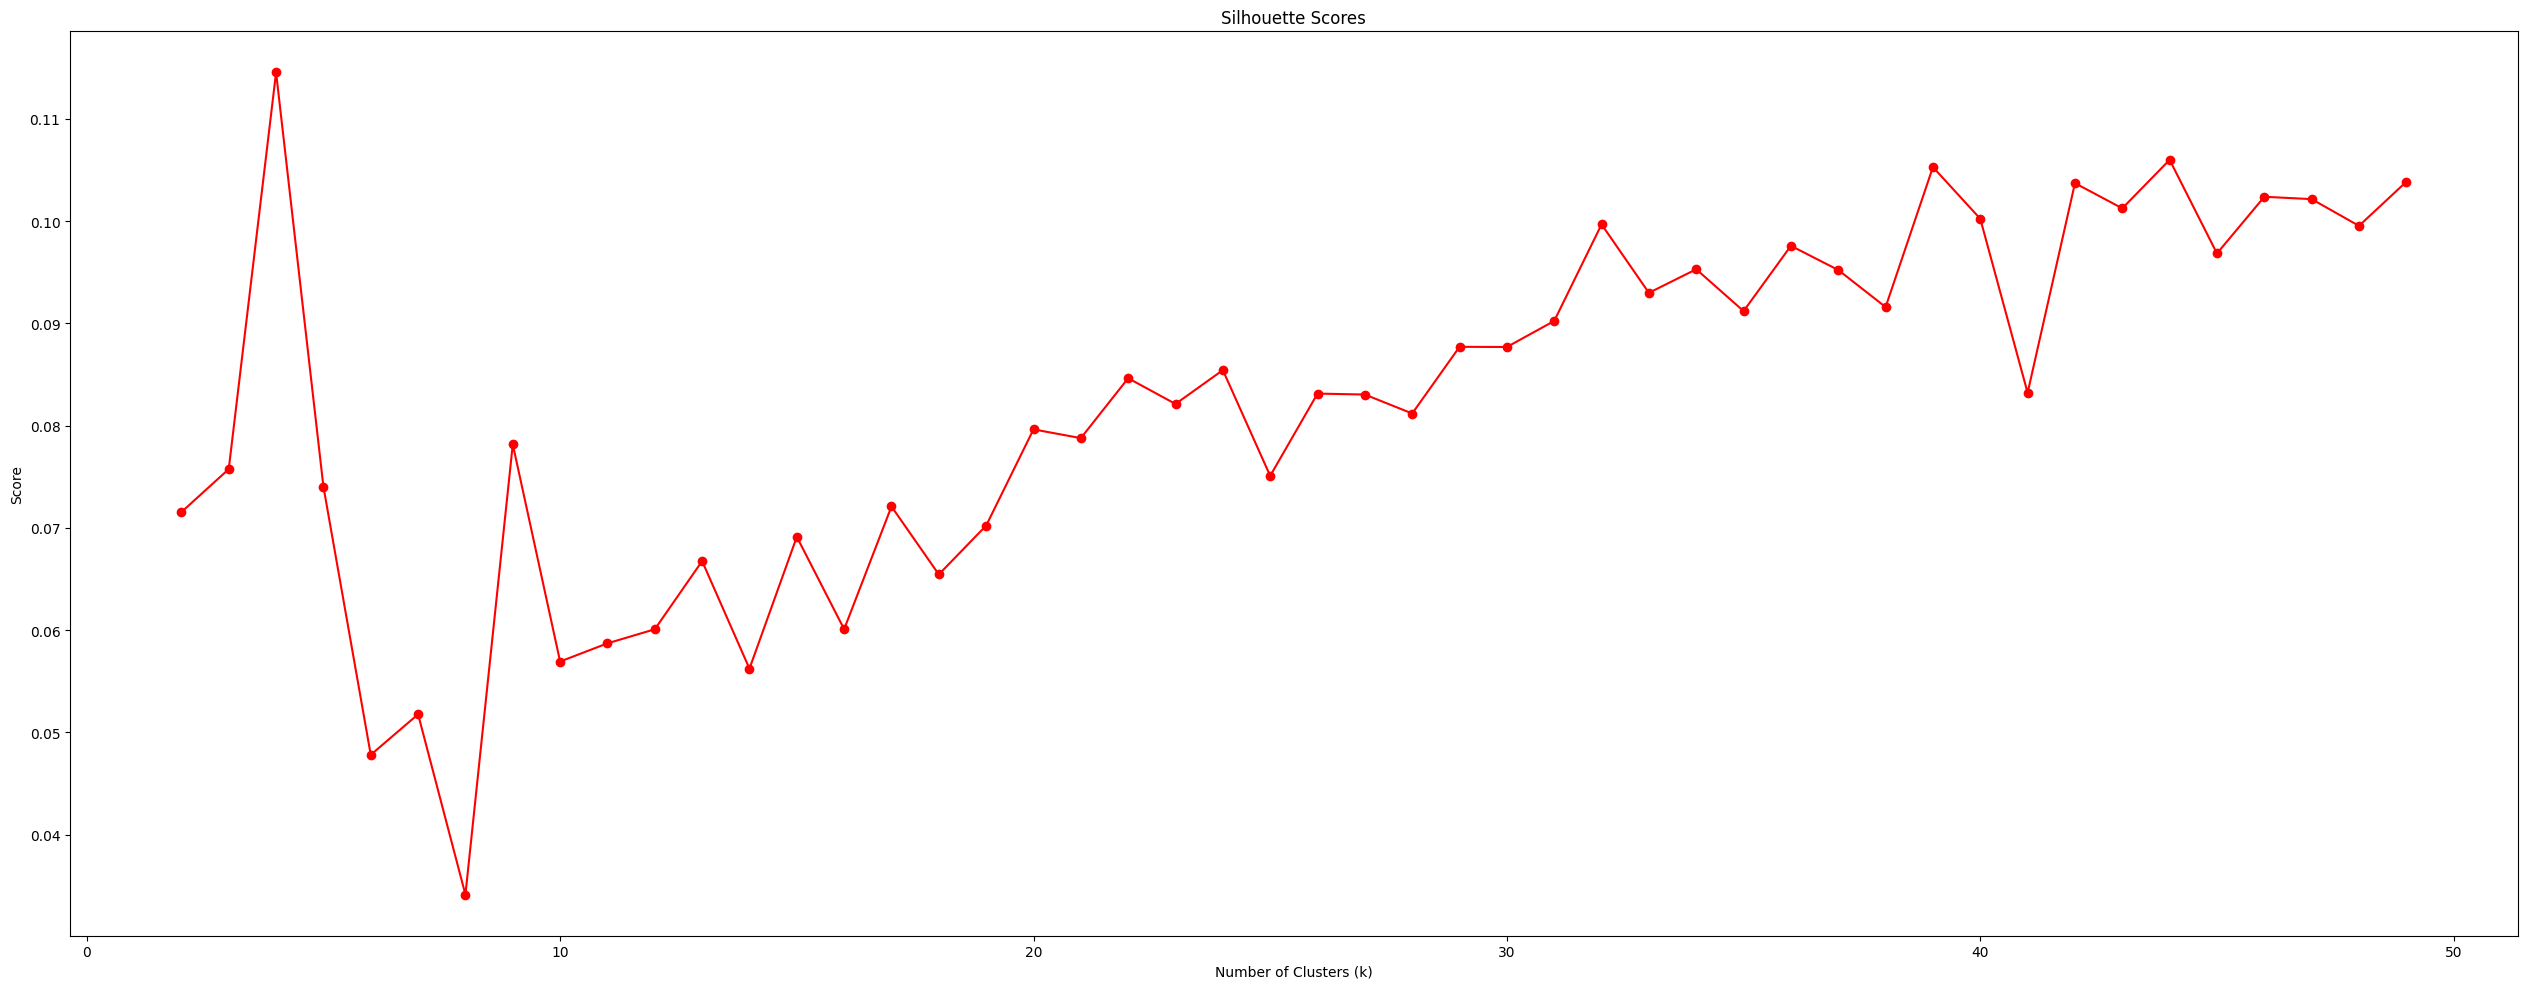

In [36]:
plt.figure(figsize=(50, 10))
plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores, marker='o', color='red')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

In [37]:
k=32
km = KMeans(n_clusters=k,init='k-means++',random_state=42)
km.fit(X)

KMeans(n_clusters=32, random_state=42)

In [38]:
df = pd.DataFrame({
    "tweet": lemmetized_tweet,
    "cluster": km.labels_
})

In [39]:
df.head()

,tweet,cluster
0,associate two apple account one device,0
1,no stunning not many prayer said cruel barbari...,2
2,hey want cancel order reference,2
3,guess forgot doo doo brown service,4
4,feature not like io turn simple turn,25


In [40]:
for i in range(k):
    print(f"\nCLUSTER {i}")

    cluster_samples = df[df["cluster"] == i]["tweet"].head(10)

    for tweet in cluster_samples:
        print(tweet)


CLUSTER 0
associate two apple account one device
come listening music keep pausing ’ sorry listen spotify not apple music spotify simply better ’ sick shit apple
way pin playlist apple music top easy access specifically carplay
ever since updating series apple watch latest o nike run app stink anything mile freeze 😡
apple not begin fixing everyone ’ phone ’ great idea right
’ got io no go black apple logo appears
phone stop go straight apple logo restarts several minute everything shuts apps updated started post-installation
correct “ show apple music ” “ icloud music library ” enabled
not everyone smart tv apple tv watch stuffthat ’ rely cable
getting anymore stock mm rose gold apple watch

CLUSTER 1
resolved thanks
nah ’ fine thanks j
thanks imaginary gin
thanks ’ try
’ resent message thanks
thanks
dealt thanks response
joking bring weekend time thanks
frustrating thanks info
thanks lot

CLUSTER 2
no stunning not many prayer said cruel barbaric way killing poor animal
hey want cance

In [41]:
terms = vectorizer.get_feature_names_out()

In [42]:
order_centroids = km.cluster_centers_.argsort()[:, ::-1]

for i in range(km.n_clusters):
    print(f"\nCluster {i} keywords:")

    top_words = [terms[ind] for ind in order_centroids[i, :10]]

    print(top_words)


Cluster 0 keywords:
['apple', 'music', 'apple music', 'apple watch', 'phone', 'io', 'watch', 'iphone', 'apple tv', 'tv']

Cluster 1 keywords:
['thanks', 'thanks help', 'ok thanks', 'help', 'ok', 'great', 'lot', 'ah', 'working', 'work']

Cluster 2 keywords:
['not', 'no', 'get', 'help', 'time', 'please', 'still', 'one', 'day', 'flight']

Cluster 3 keywords:
['getting', 'keep getting', 'keep', 'not', 'not getting', 'error', 'help', 'getting error', 'getting back', 'back']

Cluster 4 keywords:
['service', 'customer', 'customer service', 'no', 'worst', 'not', 'ever', 'great', 'service ever', 'worst customer']

Cluster 5 keywords:
['ni', 'que', 'por', 'pues', 'vez', 'porque', 'una', 'final', 'nada', 'ha']

Cluster 6 keywords:
['google', 'chrome', 'window', 'device', 'wifi', 'september', 'pixel', 'approved', 'no update', 'ethernet']

Cluster 7 keywords:
['coming', 'keep coming', 'not coming', 'yet', 'keep', 'not', 'tech', 'tomorrow', 'like', 'thanks']

Cluster 8 keywords:
['machine', 'please

## DBSCAN

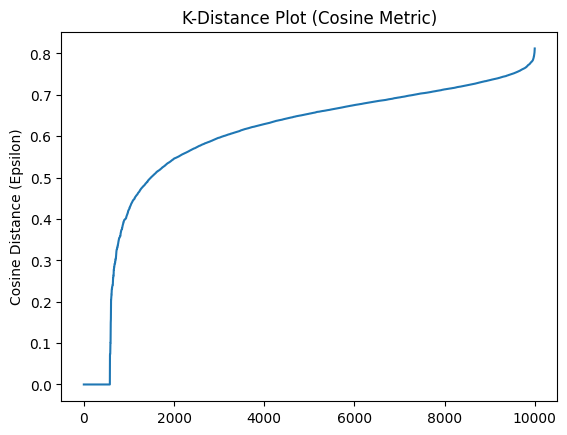

In [43]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5, metric='cosine')
nn.fit(X)
distances, indices = nn.kneighbors(X)

import matplotlib.pyplot as plt
plt.plot(np.sort(distances[:, 4], axis=0))
plt.title("K-Distance Plot (Cosine Metric)")
plt.ylabel("Cosine Distance (Epsilon)")
plt.show()

In [44]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import davies_bouldin_score

In [45]:
reduced_X.shape

(10000, 100)

In [46]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer(copy=False)

X_reduced = normalizer.fit_transform(reduced_X)

In [47]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.4,
    min_samples=5,
    metric='cosine'
)

labels = dbscan.fit_predict(X_reduced)

In [48]:
import numpy as np

if len(np.unique(dbscan.labels_)) > 1:
    print(silhouette_score(X_reduced,labels))
else:
    print(np.nan)

nan


In [49]:
from sklearn.manifold import TSNE

In [51]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_2d = tsne.fit_transform(X.toarray())

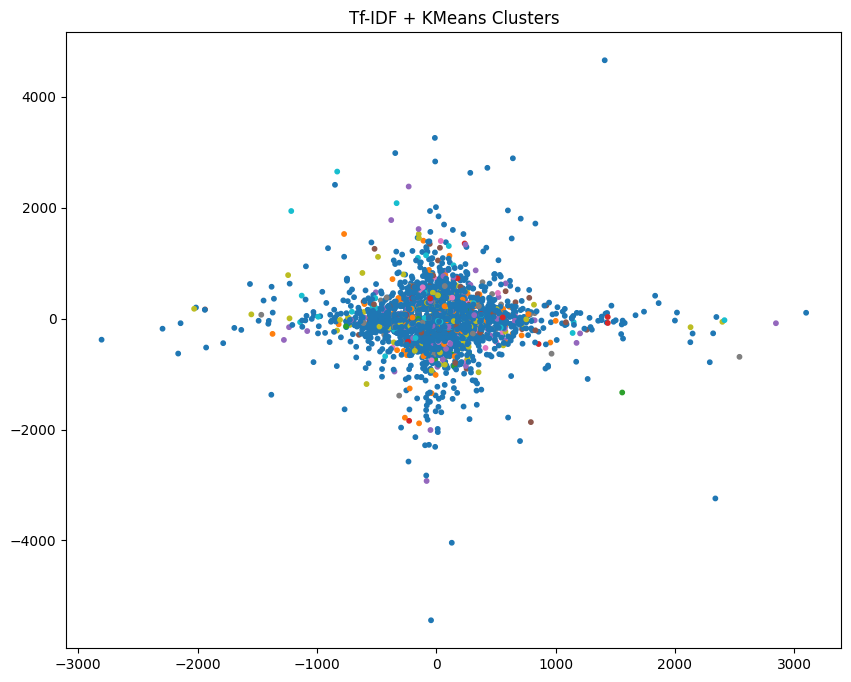

In [53]:
plt.figure(figsize=(10,8))

plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=km.labels_,
    cmap='tab10',
    s=10
)

plt.title("Tf-IDF + KMeans Clusters")
plt.show()

In [54]:
cluster_names = {
    0: "Apple Issues",
    1: "Positive Responses",
    2: "General Complaints",
    3: "Errors & Login",
    4: "Service Complaints",
    5: "Spanish Messages",
    6: "Chrome & Connectivity",
    7: "Delayed Support",
    8: "Ticketing Problems",
    9: "Chat & Booking",
    10: "DM Verification",
    11: "German Messages",
    12: "Resolved Responses",
    13: "Callback Issues",
    14: "Email & Accounts",
    15: "Codes & Queries",
    16: "General Discussion",
    17: "Sprint Network",
    18: "Successful Resolution",
    19: "DM Support",
    20: "Order & Email IDs",
    21: "Random Discussions",
    22: "Christmas Promotions",
    23: "DM Followups",
    24: "Emotional Reactions",
    25: "iPhone Battery",
    26: "Appreciation",
    27: "Lifestyle Posts",
    28: "Xbox Gaming",
    29: "Internet Outages",
    30: "Brand Engagement",
    31: "Ride Booking"
}

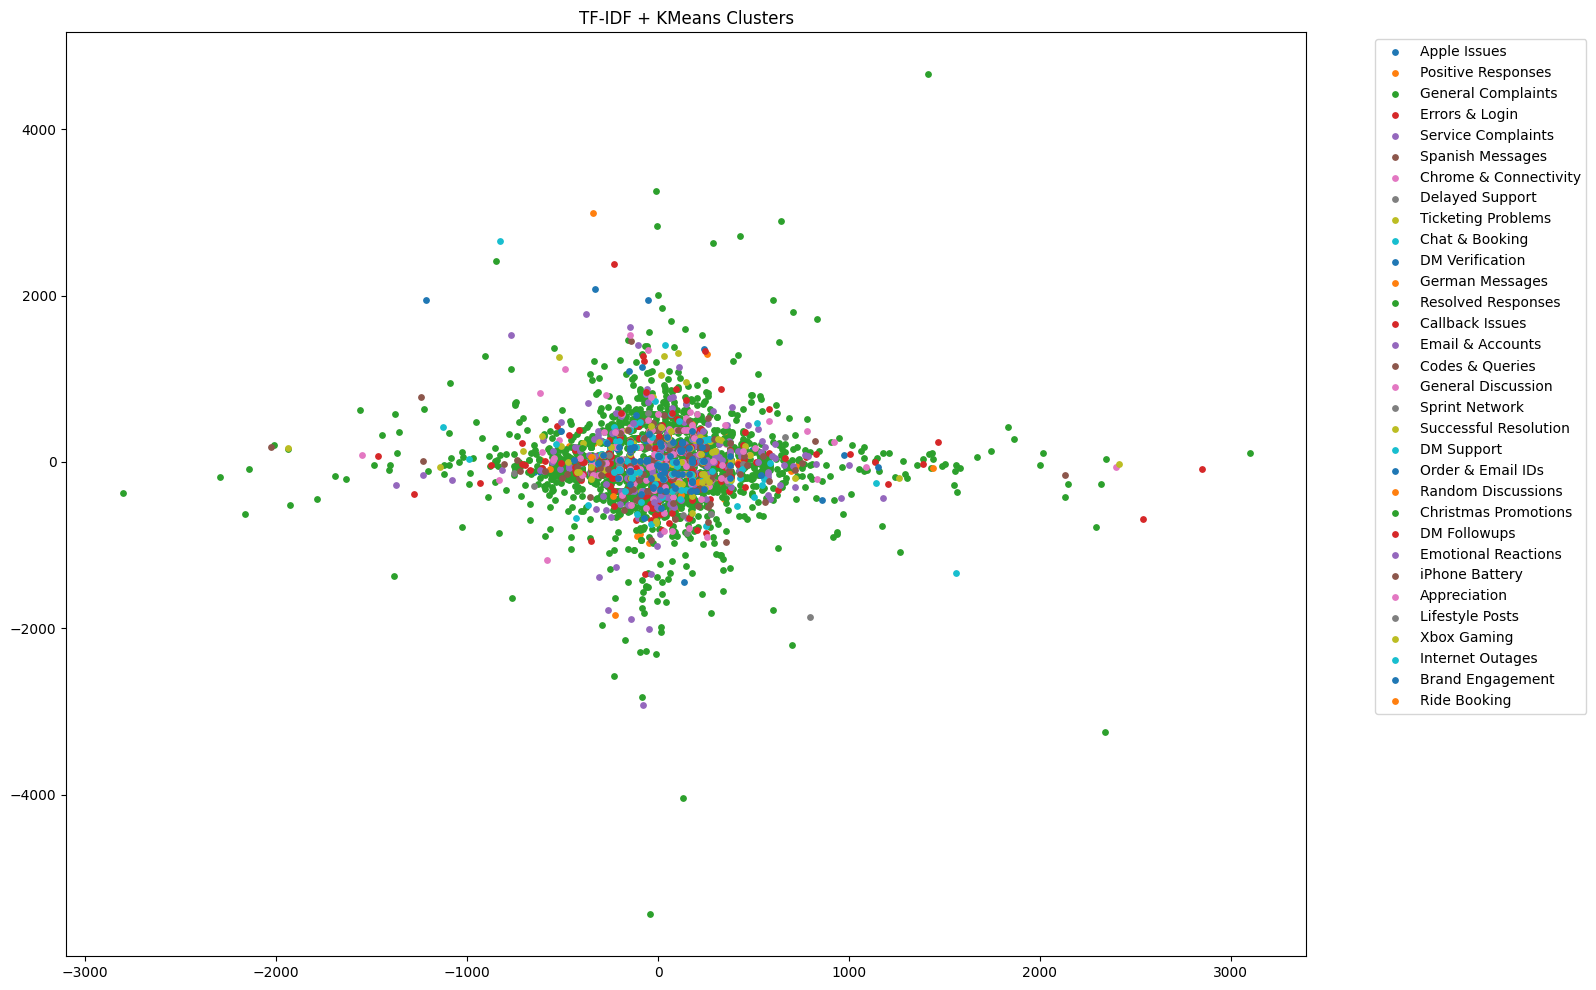

In [58]:
plt.figure(figsize=(16,12))

for cluster_id in np.unique(km.labels_):

    indices = km.labels_ == cluster_id

    plt.scatter(
        X_2d[indices, 0],
        X_2d[indices, 1],
        label=cluster_names[cluster_id],
        s=15
    )

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)

plt.title("TF-IDF + KMeans Clusters")

plt.show()